<a href="https://colab.research.google.com/github/jonay-lab/Assignment_Practice/blob/main/final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#                 Final Project
# Introduction to Artificial Intelligence

**Objective :**

To show case all gained knowledge in Introduction Artificial Intelligence course for solving business problem using specific data.


**Data source:**

 Kaggle IBM HR Analytics Employee Attrition & Performance

**Reason for selecting the data**

I selected this dataset because employee attrition is a common business problem that can affect a company's productivity and profit.The dataset contains enough employee information to analyze the reasons behind attrition and helps me apply the knowledge and skills gained throughout this course.

**Problem statement :**

why workers are leaving the Company(attrition)?

Employees are the ones who run the business, so studying them is very crucial because they are the backbone of the company. Losing employees means losing valuable experience and knowledge. This can reduce productivity, affect the company's performance, and ultimately impact its profit. Therefore, understanding the factors that lead to employee attrition is important for helping the company improve employee retention and overall business performance.


**The expected insight or question to be answered?**

what  factors are made to employee attrition?

what type of measures should the company take to improve those factors to ward improvement of the company?

which departments faces more the attrition problem?

**Importing neccessary libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Loading the data set**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Data_set/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head(2)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7


In [ ]:
print(df.shape)
df.columns

(1470, 35)


Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

Dataset contains 1470 rows and 35 columns.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                


Before changing the columns to the correct data types, it is important to explore the dataset. this is done by examining each column separately, which helps identify the appropriate metrics, understand the content of each column, and determine the correct data type.

In [ ]:
# first part
df[['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education']].head(2)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education
0,41,Yes,Travel_Rarely,1102,Sales,1,2
1,49,No,Travel_Frequently,279,Research & Development,8,1


In [ ]:
# second part
df[['EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement']].head(2)

,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement
0,Life Sciences,1,1,2,Female,94,3
1,Life Sciences,1,2,3,Male,61,2


In [ ]:
# third part
df[['JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked']].head(2)

,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked
0,2,Sales Executive,4,Single,5993,19479,8
1,2,Research Scientist,2,Married,5130,24907,1


In [ ]:
# fourth part
df[['Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel']].head(2)

,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel
0,Y,Yes,11,3,1,80,0
1,Y,No,23,4,4,80,1


In [ ]:
# fifth part
df[['TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']].head(2)

,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,8,0,1,6,4,0,5
1,10,3,3,10,7,1,7


From the above  view those need to be change to category the data type.

In [ ]:
df[['Attrition','BusinessTravel','Department']]=df[['Attrition','BusinessTravel','Department']].astype('category')
df[['EducationField', 'Gender']]=df[['EducationField', 'Gender']].astype('category')
df[[ 'JobRole','MaritalStatus']] = df[[ 'JobRole','MaritalStatus']].astype('category')
df['OverTime'] = df['OverTime'].astype('category')

**Cleaning the data set**

In [ ]:
df.isnull().sum()
df.isin(["NA", "N/A", "Unknown"]).sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


the data set has no missing values.

**Remove irrelevant or low-value features:**



In [ ]:
df.drop(columns=['EmployeeCount','EmployeeNumber','Over18','StandardHours',
                 'DailyRate','HourlyRate','MonthlyRate','PercentSalaryHike',
                 'PerformanceRating','TrainingTimesLastYear'],inplace=True)


the above columns were removed because the provided little or no value to the analysis. columns such as employeecount, over18, standardhours,contain the same value for all employees,
while employeenumber is just record. the remaining columns( dailyrate, hourlyrate, monthlyrate , precentsalaryhike, performancerating, and trainingtimelastyear) were excluded because they were not directly relevant to the objectives of this project and to simplify the analysis by focusing on the factors most related to employee attrition.

**Summary of dataset**

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.0,4.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.0,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.0,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.0,4.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0
RelationshipSatisfaction,1470.0,2.712245,1.081209,1.0,2.0,3.0,4.0,4.0



The summary statistics did not reveal any obvious abnormal or invalid values. all numerical variables fall within reasonable ranges.although monthlyIncome shows greater variability than other variables, this is expected due to differences in employee job levels and positions.

**Relation with target variables(attrition)**

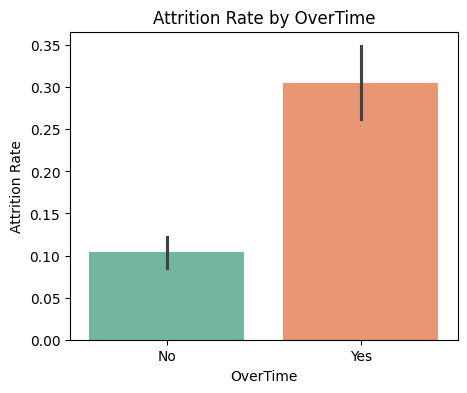

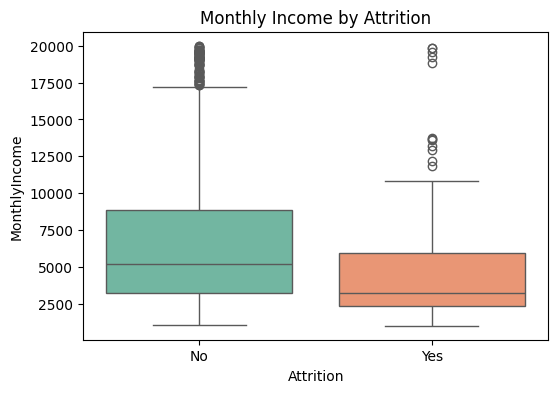

/tmp/ipykernel_2614/33466087.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  role_attr = df.groupby('JobRole')['Attrition'].apply(lambda x: (x=='Yes').mean()).sort_values(ascending=False)


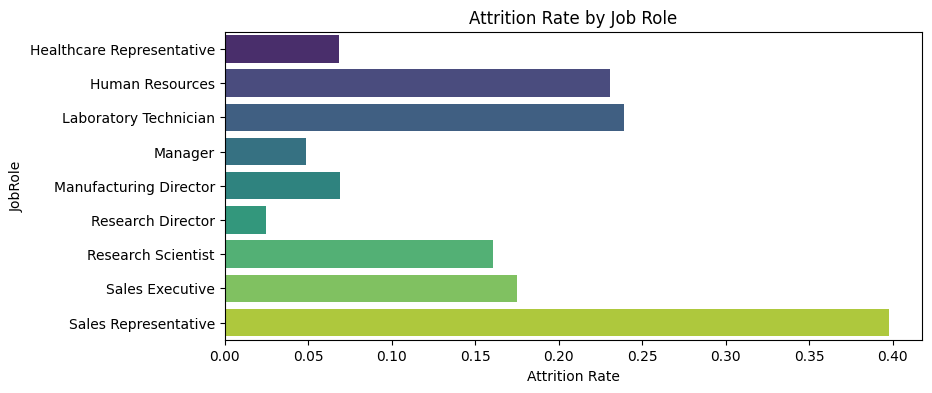

In [ ]:
#  Attrition vs OverTime
plt.figure(figsize=(5,4))
sns.barplot(data=df, x='OverTime', y=(df['Attrition']=='Yes').astype(int),
            hue='OverTime', palette='Set2', legend=False, dodge=False)
plt.ylabel('Attrition Rate')
plt.title('Attrition Rate by OverTime')
plt.show()

# Attrition vs Monthly Income
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition',
            palette='Set2', legend=False, dodge=False)
plt.title('Monthly Income by Attrition')
plt.show()

#. Attrition vs Job Role
plt.figure(figsize=(9,4))
role_attr = df.groupby('JobRole')['Attrition'].apply(lambda x: (x=='Yes').mean()).sort_values(ascending=False)
sns.barplot(x=role_attr.values, y=role_attr.index, hue=role_attr.index,
            palette='viridis', legend=False, dodge=False)
plt.xlabel('Attrition Rate')
plt.title('Attrition Rate by Job Role')
plt.show()

**Correlation between numeric features**

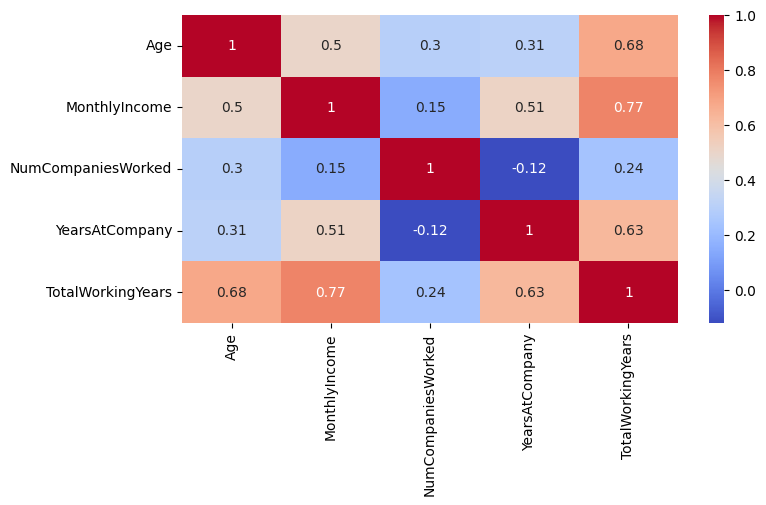

In [ ]:
corr = df[['Age','MonthlyIncome','NumCompaniesWorked',
           'YearsAtCompany','TotalWorkingYears']].corr()
plt.figure(figsize=(8,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()



The correlation analysis shows that totalworking years and monthlyincome have strong positive relationship(0.77) , indicating that employees with more experience generally earn higher salaries. these features may provide overlapping information but are both useful for predicting employee attrition, as income and experience can influence job satisfaction.
correlation shows relationships between variables but does not prove causation. and relationship between age and totalworking years(0.68) is logical ,showing that older employees typically have more work experience , suggesting the dataset has meaningful and realistic patterns.
others since no correlations are above 0.90, there is no major multicollinearity issue.

**Check class imbalance in target variable**

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


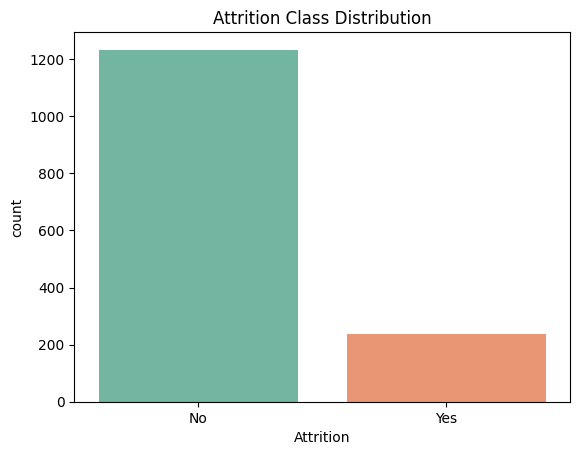

In [ ]:
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True) * 100)

sns.countplot(data=df, x='Attrition', hue='Attrition', palette='Set2', legend=False)
plt.title('Attrition Class Distribution')
plt.show()

The countplot shows there is significant class imbalance  (about 84% "No" vs 16% "Yes") —


**Encoding**

there are two common types of encoding used to convert categorical data into numerical values.

1.label encoding

used for categorical variables with two categories(binary values).
each category is assigned a numerical value

2.one-hot encoding (creating Dummy variables)

used for categorical variables with more than two categories.
creates separates binary columns for each category to avoid implying any order between categories.

In [ ]:
le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])
df['Gender']    = le.fit_transform(df['Gender'])
df['OverTime']  = le.fit_transform(df['OverTime'])

df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField',  'JobRole','MaritalStatus'], drop_first=True)
print("Shape after encoding:", df.shape)

Shape after encoding: (1470, 39)


**Splitting the data**

Splitting features and target values into train and test values.

In [ ]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

**Model Selectioon and Development**

since the target variable (attrition) is binary (yes/no) , this is a binary classification problem. therefore, I can use classification models such as logistic regression and random forest classifier to predict whether an employee will leave or stay.

**logistic regression model and  Evaluation of the model**

I standarlized features after the data is splitted to avoid data leakage


In [ ]:
from sklearn.model_selection import GridSearchCV

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train, y_train)

print("Best Params:", lr_grid.best_params_)
print("Best CV ROC-AUC:", lr_grid.best_score_)

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test)
y_proba_lr = best_lr.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

Best Params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV ROC-AUC: 0.8346605245616733
Accuracy: 0.782312925170068
Confusion Matrix:
 [[197  50]
 [ 14  33]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86       247
           1       0.40      0.70      0.51        47

    accuracy                           0.78       294
   macro avg       0.67      0.75      0.68       294
weighted avg       0.85      0.78      0.80       294



True Negative (197): The model correctly predicted 197 employees who stayed in the company.

False Positive (50): The model incorrectly predicted 50 employees would leave, but they actually stayed.

False Negative (14): The model failed to identify 14 employees who actually left.

True Positive (33): The model correctly identified 33 employees who left.





Class 0 (Employees who stayed):
Precision: 0.93 → When the model predicts an employee will stay, it is correct 93% of the time.

Recall: 0.80  The model successfully identifies 80% of employees who stayed.
Class 1 (Employees who left):

Precision: 0.40 When the model predicts an employee will leave, it is correct 40% of the time.

Recall: 0.70 The model only detects 70% of actual employees who leave.

**Randomforest classifier  model & Evaluation of the model**

In [ ]:
rf_pipeline = RandomForestClassifier(random_state=42, class_weight='balanced')

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Best Params:", rf_grid.best_params_)
print("Best CV ROC-AUC:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Best Params: {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 200}
Best CV ROC-AUC: 0.8064362567702135
Accuracy: 0.8333333333333334
Confusion Matrix:
 [[233  14]
 [ 35  12]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.94      0.90       247
           1       0.46      0.26      0.33        47

    accuracy                           0.83       294
   macro avg       0.67      0.60      0.62       294
weighted avg       0.80      0.83      0.81       294



True Negative (233): The model correctly predicted 233 employees who stayed in the company.

False Positive (14): The model incorrectly predicted 14 employees would leave, but they actually stayed.

False Negative (35): The model failed to identify 35 employees who actually left.

True Positive (12): The model correctly identified 12employees who left.



Class 0 (Employees who stayed):
Precision: 0.87 → When the model predicts an employee will stay, it is correct 87% of the time.

Recall: 0.94 → The model successfully identifies 94% of employees who stayed.

Class 1 (Employees who left):


Precision: 0.46 → When the model predicts an employee will leave, it is correct 46% of the time.
Recall: 0.26 → The model only detects 26% of actual employees who leave.

**Comparison Between Logistic Regression and Random Forest Models**

Tuned Logistic Regression achieved an accuracy of 78.2% and showed better performance in identifying employees who left, with an attrition recall of 70%. This means it was more effective at detecting employees at risk of leaving, although it produced more false positives.

Random Forest achieved an accuracy of 83.3% (based on the new results) and performed better in predicting employees who stayed, with a recall of 94% for Class 0. However, it struggled to identify employees who left, with an attrition recall of only 26%.


**Overall Conclusion:**

Random Forest achieved higher overall accuracy, but Tuned Logistic Regression was more effective for the main objective of attrition prediction because it identified more employees who were likely to leave. Since detecting potential attrition cases is important, recall for the attrition class is a key evaluation metric. Both models were affected by class imbalance.

**Add ROC-AUC curves for both models**

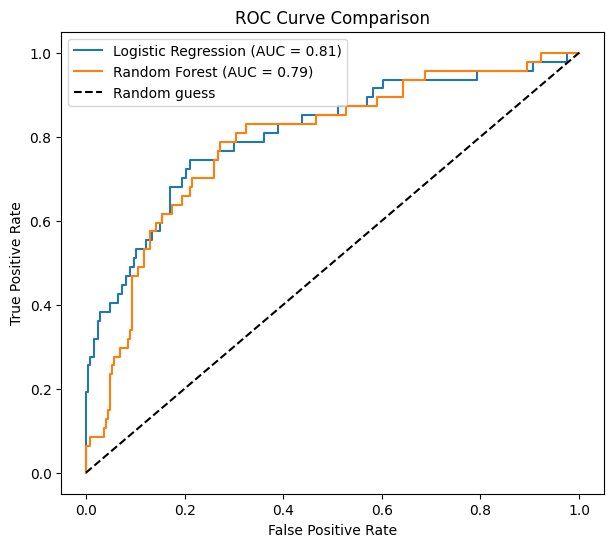

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

**Feature Importance**

**Coefficient In Logistic Regression Model **

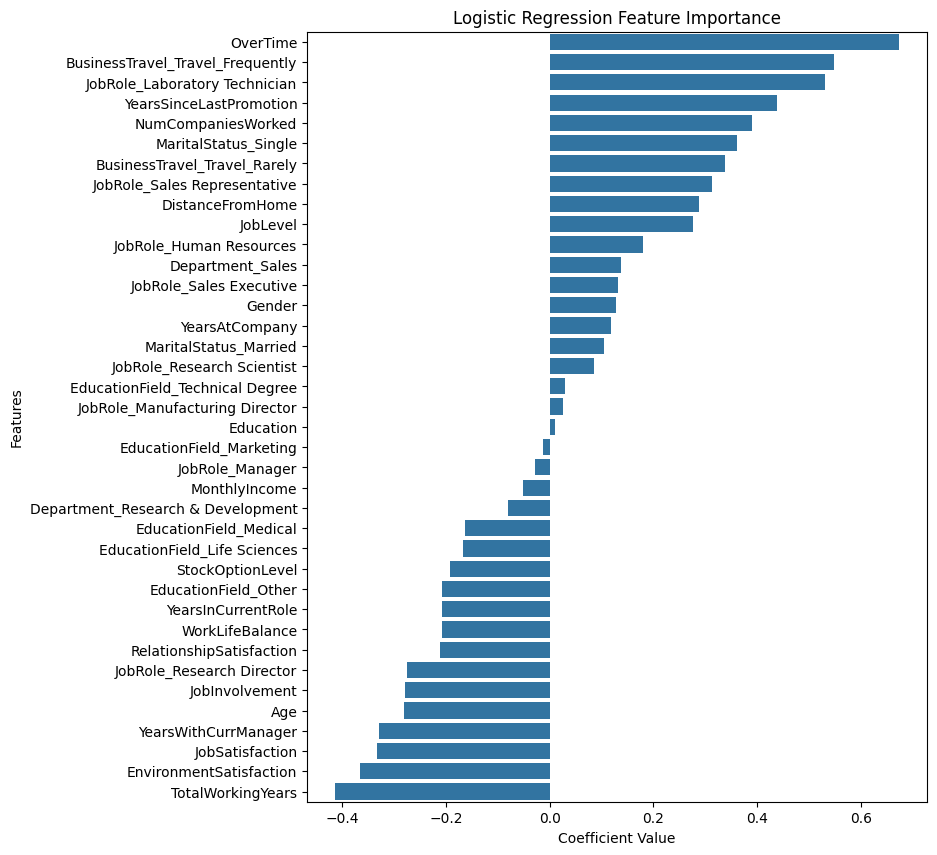

In [ ]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.named_steps['model'].coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8,10))

sns.barplot(data=importance,x='Coefficient',y='Feature')

plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()


In logistic model the most influential factors associated with employee attrition are OverTime, frequent business travel, Laboratory Technician role, lack of promotion, and the number of companies previously worked for.

**Features Coefficient in RandomForest Model**

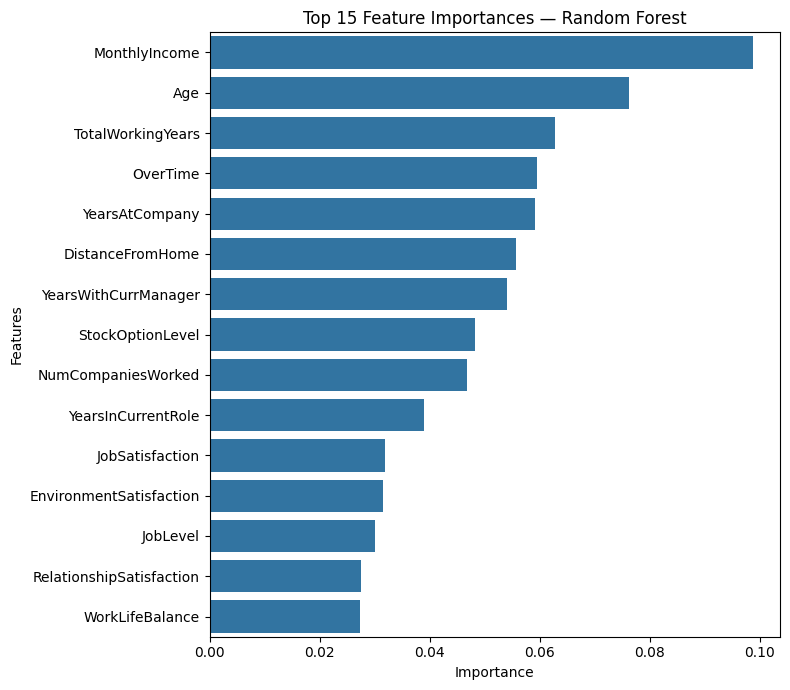

In [ ]:
importances = pd.Series(best_rf.feature_importances_,index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,7))
sns.barplot(x=importances.head(15).values,y=importances.head(15).index)
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

The Random Forest model identified MonthlyIncome, Age, TotalWorkingYears, DistanceFromHome, and YearsAtCompany as the most influential factors for predicting employee attrition.

**Conclusion**

The two models produced different feature rankings because they use different methods to evaluate variables. Logistic Regression uses coefficients to show the direction and strength of a feature's impact on attrition, while Random Forest uses feature importance scores to measure how much each variable contributes to prediction accuracy. Therefore, a feature may appear highly important in one model and less important in the other.
over all the analysis shows that overtime, monthly income, business travel, years since last promotion, distance from home, age, total working years, and job role are the main factors influencing employee attrition. In addition, job satisfaction, environment satisfaction, and work-life balance also play an important role, with lower satisfaction levels increasing the likelihood of employees leaving the company.

**the colab link **  